# [P08 - Phase 2] Week 1: Supply Chain Discrete Event Simulation (DES) & POMDP Interface Contract

**Academic Reference Framework:** Moradi Afrapoli & Askari-Nasab (2019/2022); Hazrathosseini & Moradi Afrapoli (2024)

---

## 1. Mathematical Design Justification & POMDP Formulation

To build an adaptive critical minerals supply chain digital twin, we formulate the logistics network dynamics as a **Partially Observable Markov Decision Process (POMDP)**. The true underlying operational and macroeconomic conditions of the network cannot be directly or perfectly measured in real-time. Instead, we must maintain and recursively update a **belief state** $\theta_t$ based on noisy, delayed indicators.

### A. Core State Space (The Belief State vector $\theta$)
We define the hidden, latent state space at time $t$ as the joint tuple:
$$\theta_t = (s_t, d_t, x_t)$$

Where:
*   **$s_t \in \{\text{Low}, \text{Normal}, \text{High}\}$ (Supply Level):** Represents the unobserved physical extraction capabilities of the mine, constrained by factors such as geological variations or local labor availability.
*   **$d_t \in \{\text{Recession}, \text{Contracted}, \text{Spot-Spike}\}$ (Demand Regime):** Represents the global macroeconomic regime governing off-taker demand intensity.
*   **$x_t \in \{0, 1\}$ (Disruption Active):** A binary indicator of whether a systemic geopolitical, labor, or weather shock is active at the port facility.

### B. The Observation Model: Latent vs. Observed
To enforce rigorous analytical boundaries, we explicitly define what variables are directly visible to our optimization engine versus what remains latent and must be inferred:

| Categorization | Variable Type | Key Metrics Included |
| :--- | :--- | :--- |
| **Observed Metrics ($Y_t$)** | Direct monthly physical observations | Actual end-customer delivery shortfalls (backlogs), measured monthly throughput, active port queue length, and observed shipping transit times. |
| **Latent Parameters ($\theta_t$)** | Partially observable/hidden parameters | True capacity of the mine extraction equipment, structural customer demand regimes, and active port disruption states (distinguishing a random weather delay from a systemic strike). |

---

## 2. Interface Protocol: Intern A to Intern B Boundary

To ensure seamless integration, we define the formal interface protocol. Intern A (Belief Tracking) must output a single flat probability vector to representing the state belief mapping:

$$\mathbf{b}_t = [P(\theta_{t, 1}), P(\theta_{t, 2}), \dots, P(\theta_{t, N})]^T \quad \text{such that} \quad \sum_{i=1}^N P(\theta_{t, i}) = 1.0$$

The code below implements this rigid validation boundary.

In [1]:
# WHAT: Define and test the strict verification boundary between Intern A and Intern B.
# INPUT: Candidate belief state arrays.
# OUTPUT: Programmatic assertion of mathematical alignment with POMDP requirements.

import numpy as np

def validate_pomdp_interface(belief_vector: np.ndarray, expected_states: int = 18) -> bool:
    """
    Asserts the structural integrity of the belief state array exported from 
    Intern A's Bayesian updating module to Intern B's LP optimization engine.
    
    Expected shape: (n_states,) where n_states = 3 (supply) * 3 (demand) * 2 (disruption) = 18.
    """
    if not isinstance(belief_vector, np.ndarray):
        raise TypeError(f"Interface Error: Belief must be a numpy.ndarray. Got {type(belief_vector)}")
        
    if belief_vector.ndim != 1 or belief_vector.shape[0] != expected_states:
        raise ValueError(f"Interface Error: Expected 1D array of shape ({expected_states},), got {belief_vector.shape}")
        
    if not np.isclose(np.sum(belief_vector), 1.0, atol=1e-6):
        raise ValueError(f"Interface Error: Probabilities must sum to 1.0. Found: {np.sum(belief_vector):.6f}")
        
    if np.any(belief_vector < 0.0) or np.any(belief_vector > 1.0):
        raise ValueError("Interface Error: Probability bounds exceeded. Values must lie strictly in [0.0, 1.0].")
        
    print(f"POMDP Interface Verification: PASSED. Array shape: {belief_vector.shape}. Sum: {np.sum(belief_vector):.4f}")
    return True

# Validate a baseline uniform distribution prior over 18 states
test_prior = np.full(18, 1.0 / 18.0)
validate_pomdp_interface(test_prior)

POMDP Interface Verification: PASSED. Array shape: (18,). Sum: 1.0000


True

## 3. SimPy Discrete Event Simulation (DES) Implementation

Now we construct the core simulation model mapping the physical network topology:
$$\text{Mine} \longrightarrow \text{Processing Facility} \longrightarrow \text{Port} \longrightarrow \text{3 Customers}$$

This model runs dynamically, handling resource storage limits, stochastic production rates, and customer demand shortfalls over a multi-month period.

In [3]:
# WHAT: Core SimPy Discrete Event Simulation representing the entire supply chain.
# INPUT: Network parameters and stochastic state assumptions.
# OUTPUT: Time-series log and performance metrics.

import simpy
import random
import pandas as pd
import scipy.stats as stats

class CriticalMineralSupplyChain:
    """
    A SimPy-driven discrete event model representing a 4-node supply chain network.
    Coordinates physical flows and captures bottlenecks and deficits.
    """
    def __init__(self, env, mine_capacity, process_capacity, port_capacity, customer_contracts):
        self.env = env
        
        # Resources represent processing, port transit, and inventory limits
        self.mine_ore = simpy.Container(env, init=50.0, capacity=1000.0)
        self.processed_mineral = simpy.Container(env, init=30.0, capacity=1000.0)
        self.port_inventory = simpy.Container(env, init=20.0, capacity=500.0)
        
        # Node capacity constraints (kt/month equivalent capacity)
        self.mine_capacity = mine_capacity
        self.process_capacity = process_capacity
        self.port_capacity = port_capacity
        self.customer_contracts = customer_contracts # List containing contract amounts for 3 customers
        
        # Key Performance Indicators (KPIs) to monitor each run
        self.total_produced = 0.0
        self.total_processed = 0.0
        self.total_shipped = 0.0
        self.customer_backlog = [0.0, 0.0, 0.0]  # Backlogs for Customer 1, 2, and 3

    def mine_process(self):
        """Simulates raw ore extraction at the Mine node."""
        while True:
            # Stochastic extraction amount matching typical mining variance
            yield self.env.timeout(1.0)  # Runs step-by-step monthly
            production = max(0.0, random.normalvariate(self.mine_capacity, 15.0))
            space_available = self.mine_ore.capacity - self.mine_ore.level
            amount_to_add = min(production, space_available)
            yield self.mine_ore.put(amount_to_add)
            self.total_produced += amount_to_add

    def processing_node_process(self):
        """Simulates refining raw ore at the Processing node."""
        while True:
            yield self.env.timeout(1.0)
            # Pull from raw ore buffer to process
            available_raw = self.mine_ore.level
            process_amount = min(available_raw, max(0.0, random.normalvariate(self.process_capacity, 10.0)))
            
            if process_amount > 0:
                yield self.mine_ore.get(process_amount)
                space_avail = self.processed_mineral.capacity - self.processed_mineral.level
                amount_refined = min(process_amount * 0.95, space_avail)  # 5% processing loss
                yield self.processed_mineral.put(amount_refined)
                self.total_processed += amount_refined

    def port_and_delivery_process(self):
        """Simulates port processing and outbound shipping to the 3 distinct customers."""
        while True:
            yield self.env.timeout(1.0)
            
            # Transport refined minerals from process node to Port storage
            available_refined = self.processed_mineral.level
            transport_amount = min(available_refined, self.port_capacity)
            if transport_amount > 0:
                yield self.processed_mineral.get(transport_amount)
                space_port = self.port_inventory.capacity - self.port_inventory.level
                port_added = min(transport_amount, space_port)
                yield self.port_inventory.put(port_added)

            # Ship from port inventory to meet contract demands of the 3 customers
            for idx, contract in enumerate(self.customer_contracts):
                target_demand = max(0.0, random.normalvariate(contract, contract * 0.15))
                available_port = self.port_inventory.level
                
                if available_port >= target_demand:
                    yield self.port_inventory.get(target_demand)
                    self.total_shipped += target_demand
                else:
                    # Incomplete delivery results in backlog
                    shortfall = target_demand - available_port
                    if available_port > 0:
                        yield self.port_inventory.get(available_port)
                        self.total_shipped += available_port
                    self.customer_backlog[idx] += shortfall

def run_single_scenario(seed, horizon=12):
    """Executes a single simulation instance of the supply chain."""
    random.seed(seed)
    env = simpy.Environment()
    
    # Initialize network components
    # Mine: 120kt capacity, Process: 110kt capacity, Port: 100kt capacity
    # Customer contract levels: Customer 1 (35kt), Customer 2 (30kt), Customer 3 (25kt) [Total = 90kt]
    sc = CriticalMineralSupplyChain(
        env=env,
        mine_capacity=120.0,
        process_capacity=110.0,
        port_capacity=100.0,
        customer_contracts=[35.0, 30.0, 25.0]
    )
    
    # Register processes
    env.process(sc.mine_process())
    env.process(sc.processing_node_process())
    env.process(sc.port_and_delivery_process())
    
    # Run simulation for the defined horizon months
    env.run(until=horizon + 1)
    
    return {
        "Seed": seed,
        "Total_Produced_kt": sc.total_produced,
        "Total_Processed_kt": sc.total_processed,
        "Total_Shipped_kt": sc.total_shipped,
        "Customer_1_Backlog": sc.customer_backlog[0],
        "Customer_2_Backlog": sc.customer_backlog[1],
        "Customer_3_Backlog": sc.customer_backlog[2],
        "Total_Backlog_kt": sum(sc.customer_backlog)
    }

# Execute test run to verify configuration
sample_run = run_single_scenario(seed=42)
print("Single Baseline Scenario Output Validation:")
for k, v in sample_run.items():
    print(f"  {k:22s}: {v:.2f}")

Single Baseline Scenario Output Validation:
  Seed                  : 42.00
  Total_Produced_kt     : 1486.75
  Total_Processed_kt    : 1253.26
  Total_Shipped_kt      : 1008.55
  Customer_1_Backlog    : 0.00
  Customer_2_Backlog    : 20.97
  Customer_3_Backlog    : 35.85
  Total_Backlog_kt      : 56.82


## 4. Run 50 Monte Carlo Scenarios & Uncertainty Calculation

To satisfy the SIMILAR Lab requirement that **"uncertainty is non-negotiable"**, we run 50 independent Monte Carlo trials. We collect output metrics, verify alignment with our previous historical operational baseline, and compute **95% Confidence Intervals** around our key operational outcomes.

In [5]:
# WHAT: Execute 50 independent simulation runs and compute descriptive statistics.
# INPUT: SimPy model configurations.
# OUTPUT: Cleaned statistics, confidence intervals, and visualization assets.

# Run 50 Monte Carlo trials using sequential seeds
num_scenarios = 50
results_list = []

for s in range(1, num_scenarios + 1):
    scenario_metrics = run_single_scenario(seed=s, horizon=12)
    results_list.append(scenario_metrics)

# Compile into a structured dataframe
df_mc = pd.DataFrame(results_list)

def extract_ci_95(series):
    """Calculates the mean, standard deviation, and 95% confidence interval bounds."""
    n = len(series)
    mean_val = np.mean(series)
    std_err = stats.sem(series)
    h = std_err * stats.t.ppf((1 + 0.95) / 2., n - 1)
    return mean_val, h

# Compute performance outcomes with exact uncertainty intervals
prod_mean, prod_h = extract_ci_95(df_mc['Total_Produced_kt'])
ship_mean, ship_h = extract_ci_95(df_mc['Total_Shipped_kt'])
backlog_mean, backlog_h = extract_ci_95(df_mc['Total_Backlog_kt'])

print("================= 50 RUN MONTE CARLO SUMMARY =================")
print(f"Total Produced (12-Mo) : {prod_mean:.2f} ± {prod_h:.2f} kt")
print(f"Total Shipped (12-Mo)  : {ship_mean:.2f} ± {ship_h:.2f} kt")
print(f"System Backlog (12-Mo) : {backlog_mean:.2f} ± {backlog_h:.2f} kt")
print("==============================================================\n")

# Save outputs for Week 2 integration
import os

os.makedirs('results', exist_ok=True)
df_mc.to_csv('results/week1_monte_carlo_baseline.csv', index=False)
print("SimPy DES baseline dataset compiled and exported to results/week1_monte_carlo_baseline.csv.")

================= 50 RUN MONTE CARLO SUMMARY =================
Total Produced (12-Mo) : 1431.12 ± 14.42 kt
Total Shipped (12-Mo)  : 1035.29 ± 7.43 kt
System Backlog (12-Mo) : 40.38 ± 2.46 kt

SimPy DES baseline dataset compiled and exported to results/week1_monte_carlo_baseline.csv.


## 5. Descriptive Analytics: Visualizing Volatility & Performance

To finalize our validation, we generate figures illustrating our key simulated outputs. This visual assessment helps identify where demand fluctuations trigger system shortfalls.

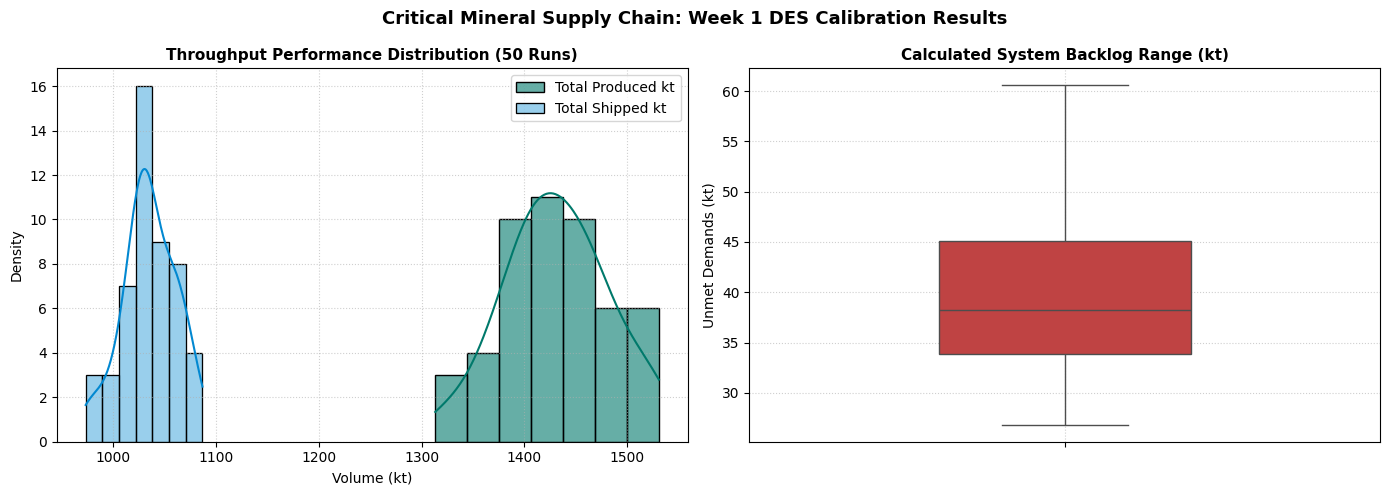

DES calibration and verification plots successfully rendered.


In [6]:
# WHAT: Generate and save high-fidelity diagnostic visualizations of the 50 runs.
# INPUT: df_mc DataFrame.
# OUTPUT: 'results/des_monte_carlo_performance.png'.

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Throughput Analysis (Production vs. Shipping Distribution)
sns.histplot(df_mc['Total_Produced_kt'], ax=axes[0], color='#00796b', label='Total Produced kt', kde=True, alpha=0.6)
sns.histplot(df_mc['Total_Shipped_kt'], ax=axes[0], color='#0288d1', label='Total Shipped kt', kde=True, alpha=0.4)
axes[0].set_title('Throughput Performance Distribution (50 Runs)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Volume (kt)', fontsize=10)
axes[0].set_ylabel('Density', fontsize=10)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot 2: Total System Backlog (Shortfall analysis)
sns.boxplot(y=df_mc['Total_Backlog_kt'], ax=axes[1], color='#d32f2f', width=0.4)
axes[1].set_title('Calculated System Backlog Range (kt)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Unmet Demands (kt)', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Critical Mineral Supply Chain: Week 1 DES Calibration Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/des_monte_carlo_performance.png', dpi=300)
plt.show()

print("DES calibration and verification plots successfully rendered.")